In [15]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import re, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

NOTEBOOK_DIR = Path('.').resolve()
PARENT       = NOTEBOOK_DIR.parent
IOT_BASE     = PARENT / 'Iot team data collected'
BLATT_FILE   = NOTEBOOK_DIR / 'blattmann_processed.xlsx'

FEATURES     = ['temperature', 'humidity', 'tvoc_ppb', 'eco2_ppm']
CLASS_NAMES  = ['Normal', 'Cooking', 'Fire']
RANDOM_STATE = 42

In [16]:
# map each scenario folder to a class
SCENARIO_MAP = {
    'No smoke Data':                                                          ('Normal',  0, 'message.txt'),
    'Cooking smoke data (5 minutes before event)':                            ('Normal',  0, 'message (1).txt'),
    'Cooking smoke data (during event)':                                      ('Cooking', 1, 'message (2).txt'),
    'Cooking smoke data (right after event has happened, 5 minutes)':         ('Cooking', 1, 'message (3).txt'),
    'Steam fog (data for preventing false alarms, 5 minutes before event)':   ('Normal',  0, 'message (4).txt'),
    'Steam fog (during steaming)':                                            ('Cooking', 1, 'message (5).txt'),
}

JSON_RE = re.compile(r'\{[^{}]+\}')
rows = []
for folder, (label, class_id, fname) in SCENARIO_MAP.items():
    fpath = IOT_BASE / folder / fname
    if not fpath.exists():
        print(f"missing: {fpath}"); continue
    for blob in JSON_RE.findall(fpath.read_text(errors='ignore')):
        try:
            d = json.loads(blob)
            rows.append({'label': label, 'class_id': class_id,
                         'temperature': d.get('temperature'), 'humidity': d.get('humidity'),
                         'tvoc_ppb': d.get('tvoc'), 'eco2_ppm': d.get('eco2')})
        except json.JSONDecodeError:
            pass

iot = pd.DataFrame(rows).dropna(subset=FEATURES)
print(f"IoT samples: {len(iot)}")
print(iot['label'].value_counts().to_string())

iot.drop(columns=['scenario'], errors='ignore').to_excel(NOTEBOOK_DIR / 'iot_labeled.xlsx', index=False)

IoT samples: 549
label
Cooking    329
Normal     220


In [17]:
# remap blattmann 2-class to our 3-class scheme (Smoke -> Fire)
blatt = pd.read_excel(BLATT_FILE, sheet_name='Blattmann Processed')
blatt = blatt.rename(columns={'label': 'blatt_label'})
blatt['class_id'] = blatt['blatt_label'].map({'No Smoke': 0, 'Smoke': 2})
blatt['label']    = blatt['class_id'].map({0: 'Normal', 2: 'Fire'})
blatt = blatt.dropna(subset=['class_id'] + FEATURES)
blatt['class_id'] = blatt['class_id'].astype(int)

print(f"Blattmann samples: {len(blatt):,}")
print(blatt['label'].value_counts().to_string())

Blattmann samples: 62,630
label
Fire      44757
Normal    17873


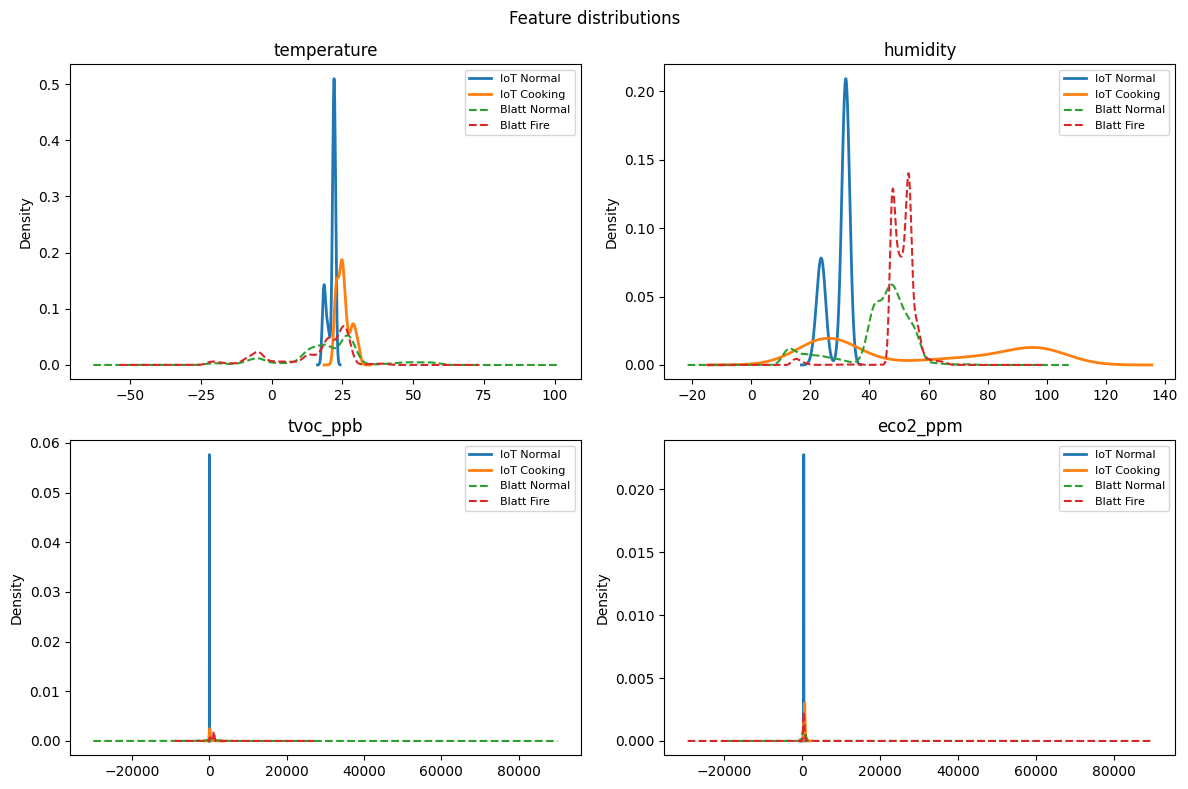

In [18]:
# feature distributions per class and dataset
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature distributions')

for ax, feat in zip(axes.flat, FEATURES):
    for cid, name in [(0, 'Normal'), (1, 'Cooking')]:
        iot[iot['class_id'] == cid][feat].plot.kde(ax=ax, label=f'IoT {name}', lw=2)
    for cid, name in [(0, 'Normal'), (2, 'Fire')]:
        blatt[blatt['class_id'] == cid][feat].plot.kde(ax=ax, label=f'Blatt {name}', lw=1.5, ls='--')
    ax.set_title(feat); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [19]:
# split each dataset separately so IoT test set isn't dominated by Blattmann's size
X_b_tr, X_b_te, y_b_tr, y_b_te = train_test_split(
    blatt[FEATURES].values, blatt['class_id'].values,
    test_size=0.2, random_state=RANDOM_STATE, stratify=blatt['class_id'].values)

X_i_tr, X_i_te, y_i_tr, y_i_te = train_test_split(
    iot[FEATURES].values, iot['class_id'].values,
    test_size=0.2, random_state=RANDOM_STATE, stratify=iot['class_id'].values)

# combine for training
X_train = np.vstack([X_b_tr, X_i_tr])
y_train  = np.concatenate([y_b_tr, y_i_tr])

print(f"Train: {len(y_train):,}  |  Blattmann test: {len(y_b_te):,}  |  IoT test: {len(y_i_te):,}")
for cid, name in enumerate(CLASS_NAMES):
    n = (y_train == cid).sum()
    if n: print(f"  {name}: {n:,}")

Train: 50,543  |  Blattmann test: 12,526  |  IoT test: 110
  Normal: 14,474
  Cooking: 263
  Fire: 35,806


In [20]:
# fit scaler on train only — applying to test avoids data leakage
scaler = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_b_test_sc = scaler.transform(X_b_te)
X_i_test_sc = scaler.transform(X_i_te)

joblib.dump(scaler, NOTEBOOK_DIR / 'scaler.joblib')

['C:\\dev\\Uni\\SEM4\\MAL\\ML-Exam-Preparation\\Semester Project ML Team\\final_model_pipeline\\scaler.joblib']

In [21]:
# balanced weights to handle class imbalance (Cooking has ~263 vs ~35k Fire samples)
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

joblib.dump(rf, NOTEBOOK_DIR / 'model_random_forest.joblib')

['C:\\dev\\Uni\\SEM4\\MAL\\ML-Exam-Preparation\\Semester Project ML Team\\final_model_pipeline\\model_random_forest.joblib']

CV F1-macro: 0.9943 +/- 0.0033


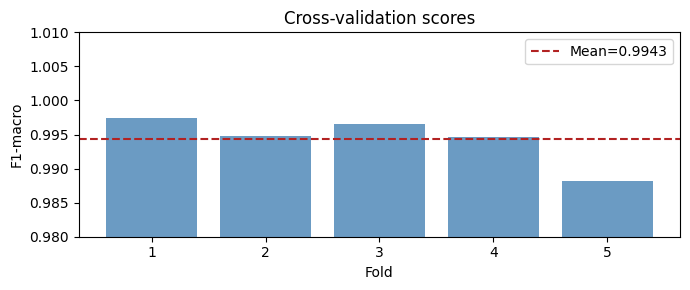

In [22]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(rf, X_train_sc, y_train, cv=skf, scoring='f1_macro')

print(f"CV F1-macro: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

plt.figure(figsize=(7, 3))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8)
plt.axhline(cv_scores.mean(), color='firebrick', ls='--', label=f'Mean={cv_scores.mean():.4f}')
plt.ylim(0.98, 1.01)
plt.xlabel('Fold'); plt.ylabel('F1-macro')
plt.title('Cross-validation scores'); plt.legend()
plt.tight_layout()
plt.show()

In [23]:
y_b_pred = rf.predict(X_b_test_sc)
y_i_pred = rf.predict(X_i_test_sc)

print("Blattmann test set")
print(classification_report(y_b_te, y_b_pred, target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

Blattmann test set
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      3575
     Cooking       0.00      0.00      0.00         0
        Fire       1.00      1.00      1.00      8951

    accuracy                           1.00     12526
   macro avg       0.66      0.66      0.66     12526
weighted avg       1.00      1.00      1.00     12526



In [24]:
print("IoT device test set")
print(classification_report(y_i_te, y_i_pred, target_names=CLASS_NAMES, labels=[0,1,2], zero_division=0))

IoT device test set
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99        44
     Cooking       1.00      0.98      0.99        66
        Fire       0.00      0.00      0.00         0

    accuracy                           0.99       110
   macro avg       0.66      0.66      0.66       110
weighted avg       0.99      0.99      0.99       110



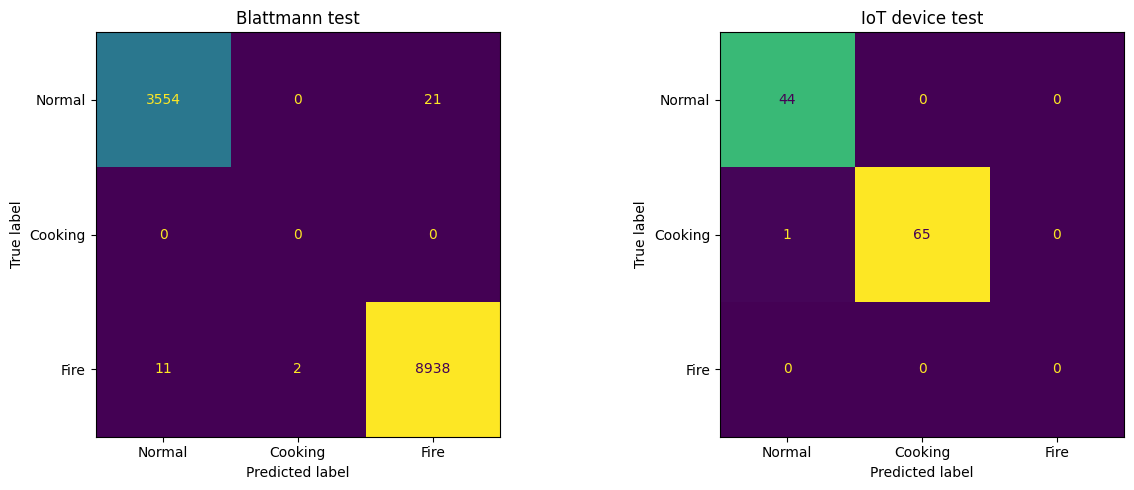

Cooking->Fire errors (IoT): 0


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_b_te, y_b_pred, 'Blattmann test'),
    (axes[1], y_i_te, y_i_pred, 'IoT device test'),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(title)

plt.tight_layout()
plt.show()

print(f"Cooking->Fire errors (IoT): {confusion_matrix(y_i_te, y_i_pred, labels=[0,1,2])[1][2]}")

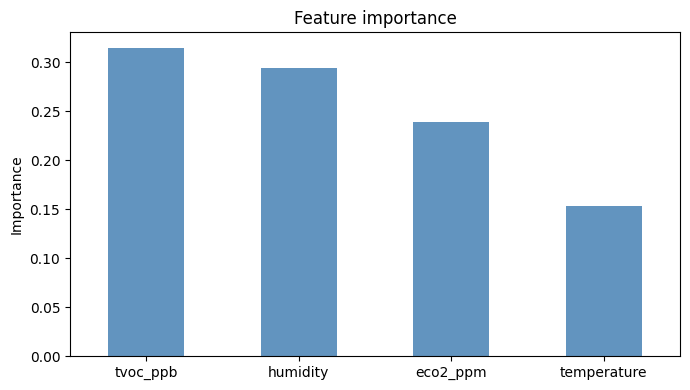

tvoc_ppb       0.3147
humidity       0.2936
eco2_ppm       0.2388
temperature    0.1528


In [26]:
fi = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(7, 4))
fi.plot.bar(color='steelblue', alpha=0.85)
plt.title('Feature importance'); plt.ylabel('Importance')
plt.xticks(rotation=0); plt.tight_layout()
plt.show()

print(fi.round(4).to_string())

In [27]:
train_f1 = f1_score(y_train, rf.predict(X_train_sc), average='macro')
cv_f1    = cv_scores.mean()
gap      = train_f1 - cv_f1

print(f"Train F1: {train_f1:.4f}  |  CV F1: {cv_f1:.4f}  |  Gap: {gap:.4f}")
print("no overfitting" if gap < 0.02 else "mild overfitting" if gap < 0.05 else "overfitting detected")

Train F1: 1.0000  |  CV F1: 0.9943  |  Gap: 0.0057
no overfitting
